# Análise Exploratória de Dados (EDA): Eventos de Rede Baseados em Change Points

Este notebook realiza uma Análise Exploratória de Dados (EDA) sobre as características (*features*) extraídas de eventos de rede. O objetivo é validar se as métricas refletem o comportamento esperado da rede antes da classificação pelo GMM.

## 1. Contexto e Parametrização

Diferente de uma análise de série temporal convencional, aqui analisamos **eventos discretos**. Cada linha do conjunto de dados representa um Change Point (CP) detectado em uma métrica de referência. As variáveis principais são:

* **Cenário (Scenario):** O conjunto de dados bruto processado.
* **Métrica de Referência (Ref Metric):** A métrica que disparou a detecção do evento.
* **Limiar (Threshold):** O nível de probabilidade exigido para validar a mudança.

Nesta etapa, carregamos o arquivo de características onde cada entrada já contém os cálculos de variação absoluta (RTT e PL) e relativa (Throughput) entre os regimes anterior e posterior ao evento.

In [68]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- Configurações de Aparência ---
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)

# --- Parâmetros do Estudo ---
SCENARIO = "NDT_AGO_OUT"
METHOD = "vwcd"
REF_METRIC = "rtt_down"
THRESHOLD = 0.95

# --- Caminho do Arquivo de Features ---
base_path = os.path.join("segments", SCENARIO, "full")
file_name = f"features_{METHOD}_{REF_METRIC}_{THRESHOLD}.csv"
full_path = os.path.join(base_path, file_name)

# --- Carregamento ---
if os.path.exists(full_path):
    # O df_ana aqui já contém os eventos (Change Points) com seus respectivos deltas
    df_ana = pd.read_csv(full_path)
    
    print(f"Dataset carregado com sucesso!")
else:
    print(f"Erro: O arquivo {full_path} não foi encontrado.")

# --- PRÉ-PROCESSAMENTO: Ajuste de Escala e Clipping ---
# 1. Ajuste da escala do Packet Loss (de percentual para probabilidade [-1, 1])
if 'd_pl' in df_ana.columns:
    df_ana['d_pl'] = df_ana['d_pl'] / 100.0

# # 2. Definição das colunas que sofrerão a Winsorização (Clipping)
# cols_to_clip = ['d_rtt_down', 'd_rtt_up', 'd_tp_down', 'd_tp_up', 'd_pl']

# # 3. Aplicação do Clipping nos percentis 1% e 99%
# for col in cols_to_clip:
#     if col in df_ana.columns:
#         lower_bound = df_ana[col].quantile(0.01)
#         upper_bound = df_ana[col].quantile(0.99)
#         # Substitui os valores extremos pelos próprios limites dos percentis
#         df_ana[col] = df_ana[col].clip(lower=lower_bound, upper=upper_bound)
        
# print("Pré-processamento estatístico aplicado: Escala ajustada e outliers limitados.")

Dataset carregado com sucesso!


## 2. Caracterização Geral do Dataset

Antes de aprofundar na análise das variações métricas, realizamos uma caracterização estrutural do conjunto de dados. Esta etapa quantifica a diversidade de clientes e servidores envolvidos e o volume total de eventos de mudança detectados. Os dados processados compreendem o período entre **{data_inicio}** e **{data_fim}**.

### Justificativa Técnica e Viabilidade do GMM

A caracterização do dataset é essencial para validar a aplicação do modelo estatístico sugerido na Seção 5 do referencial teórico:

* **Diversidade de Pares (Clientes e Servidores)**: O Modelo de Mistura Gaussiana (GMM) visa identificar comportamentos latentes da rede. Para que o modelo seja generalizável e não sofra de sobreajuste (*overfitting*) a uma única rota ou dispositivo, é necessário que os eventos tenham origem em múltiplos pares cliente-servidor.
* **Volume de Eventos (Change Points)**: Cada Change Point (CP) detectado é um ponto no espaço de características multidimensional ($x_{e} \in \mathbb{R}^{p}$). Como o GMM busca estimar médias ($\mu_{k}$) e matrizes de covariância ($\Sigma_{k}$) para dois componentes distintos, um número de eventos significativamente maior que o número de parâmetros é necessário para garantir a estabilidade das estimativas. Para $K=2$ e $D=5$, o modelo possui exatamente **41 parâmetros independentes**.
* **Frequência de Ocorrência**: A média de eventos por par ajuda a identificar se o fenômeno de instabilidade na rede é um evento raro ou recorrente. De acordo com a Seção 6.1.1 do referencial, thresholds mais elevados (como $\tau=0.95$) resultam em detecções mais confiáveis, o que deve ser refletido em um número de CPs menor, porém com maior impacto estatístico.

Ao final desta análise, esperamos confirmar se o tamanho da amostra "N" é suficiente para permitir a separação clara dos clusters de Congestionamento e Mudança de Rota, conforme as assinaturas descritas na Tabela 1 do documento.

In [69]:
# --- Cálculo de Métricas de Caracterização ---

# Extração da Janela Temporal
df_ana['timestamp'] = pd.to_datetime(df_ana['timestamp'])
data_inicio = df_ana['timestamp'].min().strftime('%m/%Y')
data_fim = df_ana['timestamp'].max().strftime('%m/%Y')

# Identificação das entidades únicas no dataset
total_clients = df_ana['client'].nunique()
total_servers = df_ana['server'].nunique()
total_pairs = df_ana.groupby(['client', 'server']).ngroups
total_events = len(df_ana)

# Cálculo da densidade de eventos por conexão
avg_cp_per_pair = total_events / total_pairs if total_pairs > 0 else 0

# Exibição do Relatório de Viabilidade
print(f"{'='*50}")
print(f" RELATÓRIO DE CARACTERIZAÇÃO DO CENÁRIO: {SCENARIO}")
print(f"{'='*50}")
print(f"Período de Análise:                 {data_inicio} até {data_fim}")
print(f"Total de Clientes únicos:           {total_clients}")
print(f"Total de Servidores únicos:         {total_servers}")
print(f"Total de Pares Cliente-Servidor:    {total_pairs}")
print(f"Total de Eventos (Change Points):   {total_events}")
print(f"Média de eventos por par:           {avg_cp_per_pair:.2f}")
print(f"{'='*50}")

# Verificação qualitativa para o GMM
if total_events > 100:
    print("Status: Volume de dados satisfatório para convergência do GMM.")
else:
    print("Aviso: Volume de dados reduzido. Os clusters podem apresentar baixa estabilidade.")

 RELATÓRIO DE CARACTERIZAÇÃO DO CENÁRIO: NDT_AGO_OUT
Período de Análise:                 08/2025 até 10/2025
Total de Clientes únicos:           15
Total de Servidores únicos:         5
Total de Pares Cliente-Servidor:    37
Total de Eventos (Change Points):   188
Média de eventos por par:           5.08
Status: Volume de dados satisfatório para convergência do GMM.


## 3. Análise de Sincronização de Métricas (Synchronization Score - $S_{e}$)

O Synchronization Score ($S_{e}$) é uma métrica fundamental definida na Seção 2.5 do referencial técnico. Ele quantifica a fração de métricas que apresentaram um Ponto de Mudança (CP) no mesmo instante de amostragem $t_{e}$ para um determinado par cliente-servidor.

### Fundamentação Teórica e Interpretação

O score é calculado como $S_{e} = \frac{1}{|\mathcal{M}|} \sum_{m \in \mathcal{M}} 1(t_{e} \in \mathcal{K}_{i,j}^{(m)})$, onde $|\mathcal{M}|=5$ representa o conjunto de métricas monitoradas (RTT up/down, TP up/down e PL). A interpretação deste score é vital para a viabilidade do GMM:

* **$S_{e} \approx 1$ (Alta Sincronização)**: Indica eventos coordenados onde múltiplas métricas mudam simultaneamente. De acordo com a Seção 3.5, eventos sistêmicos como **Congestionamento** tendem a apresentar scores elevados, pois afetam atraso, vazão e perda de forma conjunta.
* **$S_{e}$ Moderado**: Sugere uma correlação parcial, típica de mudanças de rota que afetam significativamente o RTT mas impactam apenas marginalmente a vazão disponível.
* **$S_{e} \approx 0.2$ (Baixa Sincronização)**: Representa mudanças isoladas em uma única métrica. Podem indicar ruído estatístico ou falhas pontuais que não se traduzem em uma degradação generalizada da rede.

### Importância para o GMM e Tabela 1

Esta análise ajuda a prever a formação dos clusters:
1. Esperamos que o cluster de **Congestionamento** (Componente 1) apresente médias de $S_{e}$ mais altas.
2. O cluster de **Mudança de Rota** (Componente 2) deve apresentar scores moderados a baixos, focados na métrica de RTT.
3. Se a maioria dos eventos possuir score 0.2, a viabilidade de encontrar clusters multivariados robustos diminui, indicando que as anomalias são predominantemente isoladas.

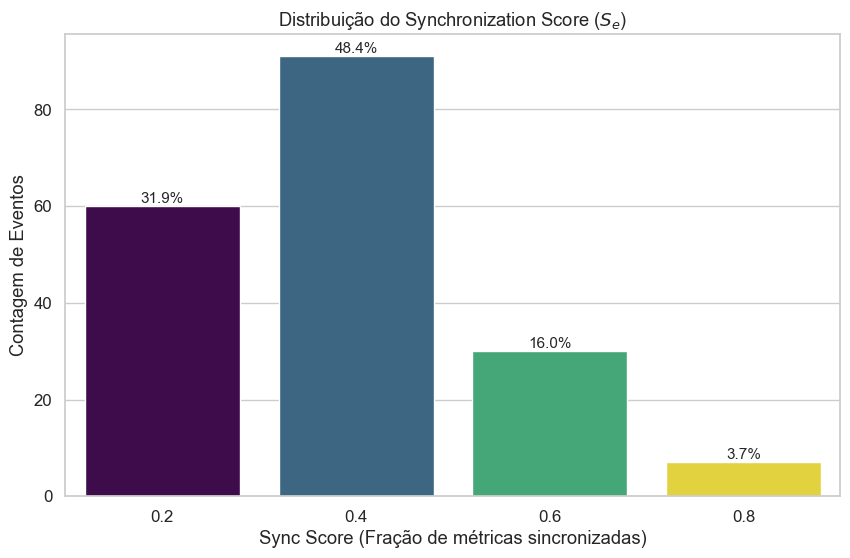

Distribuição percentual dos scores:
sync_score
0.2    31.91
0.4    48.40
0.6    15.96
0.8     3.72
Name: proportion, dtype: float64


In [70]:
# --- Análise da Frequência de Sync Scores ---

plt.figure(figsize=(10, 6))

# Contagem de ocorrências para cada nível de sincronização
# O parâmetro hue é definido como a própria variável para compatibilidade com versões recentes do Seaborn
sns.countplot(data=df_ana, x='sync_score', hue='sync_score', palette='viridis', legend=False)

plt.title("Distribuição do Synchronization Score ($S_{e}$)")
plt.xlabel("Sync Score (Fração de métricas sincronizadas)")
plt.ylabel("Contagem de Eventos")

# Adição de labels de porcentagem sobre as barras para análise de densidade
total = len(df_ana)
for p in plt.gca().patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    plt.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=11)

plt.show()

# Resumo numérico para o relatório
print("Distribuição percentual dos scores:")
print((df_ana['sync_score'].value_counts(normalize=True).sort_index() * 100).round(2))

## 4. Distribuição das Variações Métricas (Deltas)

Nesta seção, analisamos como as variações de desempenho se distribuem em todo o conjunto de eventos detectados. Diferente das métricas brutas, os "deltas" capturam a magnitude da mudança de estado da rede em um instante específico de mudança.

### Justificativa Técnica para o GMM

A forma dessas distribuições é o principal indicativo da viabilidade de um Modelo de Mistura Gaussiana:

* **Robustez Estatística**: O referencial teórico adota diferentes abordagens para cada métrica: variações absolutas para RTT e Packet Loss (PL), e variações relativas para Throughput (TP). Esta análise permite verificar se essas escalas (ms para RTT, % para TP e taxa para PL) estão operando em intervalos que não causem instabilidade numérica no modelo.
* **Identificação de "Caudas" e Outliers**: O RTT tende a apresentar distribuições de cauda longa devido a picos transientes, justificando o uso da mediana para o cálculo do delta. Visualizar essas caudas ajuda a prever quão "espalhados" serão os clusters resultantes.
* **Potencial de Discriminação**: Para que o GMM identifique três componentes distintos (Congestionamento, Rota e Gargalo), as distribuições devem idealmente apresentar multimodalidade ou, no mínimo, uma variância que sugira a existência de subpopulações de dados (ex: pequenos saltos de RTT para mudanças de rota vs. grandes saltos para congestionamento).

### O que interpretar?
Esperamos observar se a maioria dos eventos se concentra em torno de variações pequenas (ruído ou mudanças leves) e se existem "assinaturas" claras de degradação severa, que formarão os núcleos dos clusters de anomalia descritos na Tabela 1 do documento técnico.

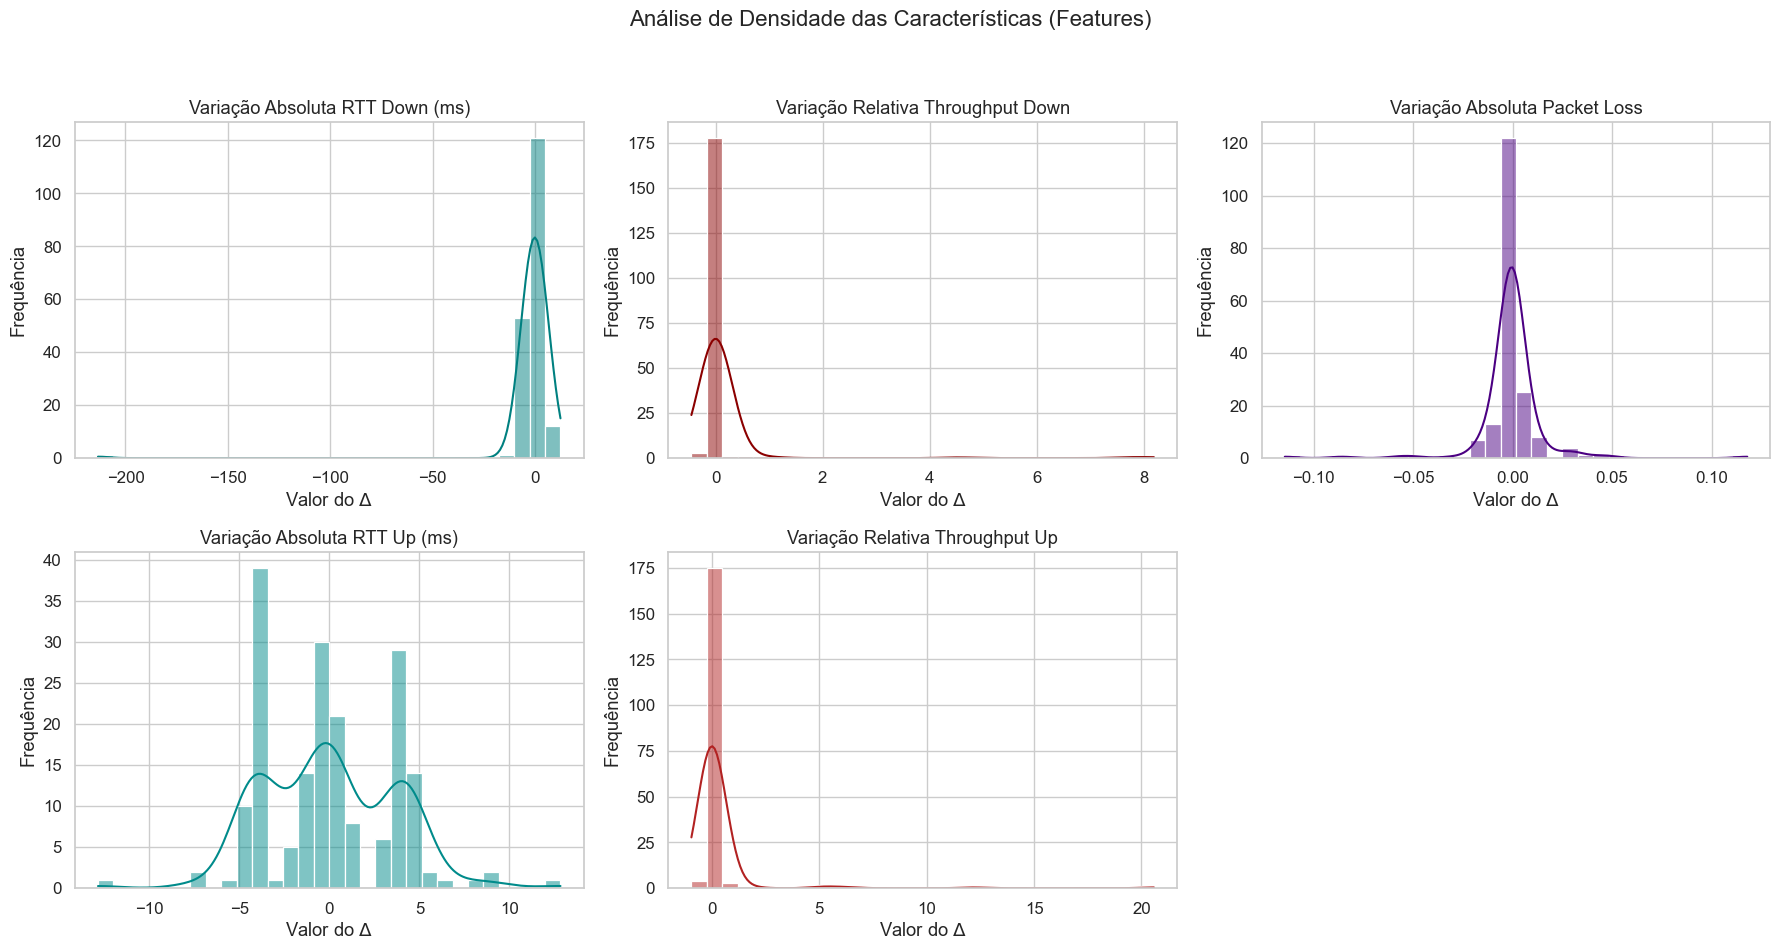

Estatísticas Descritivas das Features:
       d_rtt_down  d_tp_down      d_pl  d_rtt_up   d_tp_up
count    188.0000   188.0000  188.0000  188.0000  188.0000
mean      -1.0993     0.1190   -0.0006   -0.0054    0.2816
std       15.9968     0.8860    0.0171    3.6497    1.8775
min     -213.4055    -0.4508   -0.1144  -12.8455   -0.9537
25%       -3.8025    -0.0324   -0.0027   -3.7470   -0.0328
50%        0.0000     0.0004   -0.0001   -0.0925    0.0048
75%        3.6788     0.0367    0.0013    3.8105    0.0377
max       12.4920     8.1859    0.1180   12.8305   20.5777


In [71]:
# --- Visualização das Distribuições de Variação (Deltas) ---

# Seleção das métricas principais para análise de distribuição (Down/PL na primeira linha, Up na segunda)
metrics_to_plot = [
    ('d_rtt_down', 'Variação Absoluta RTT Down (ms)', 'teal'),
    ('d_tp_down', 'Variação Relativa Throughput Down', 'darkred'),
    ('d_pl', 'Variação Absoluta Packet Loss', 'indigo'),
    ('d_rtt_up', 'Variação Absoluta RTT Up (ms)', 'darkcyan'),
    ('d_tp_up', 'Variação Relativa Throughput Up', 'firebrick')
]

# Criação da figura com subplots para comparação lado a lado
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
plt.suptitle("Análise de Densidade das Características (Features)", fontsize=16)
axes_flat = axes.flatten()

for i, (col, label, color) in enumerate(metrics_to_plot):
    if col in df_ana.columns:
        # Uso do Kernel Density Estimate (KDE) para visualizar a forma da distribuição
        sns.histplot(df_ana[col], kde=True, color=color, ax=axes_flat[i], bins=30)
        axes_flat[i].set_title(label)
        axes_flat[i].set_xlabel("Valor do $\\Delta$")
        axes_flat[i].set_ylabel("Frequência")

fig.delaxes(axes_flat[5])
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Estatísticas descritivas para suporte à análise do GMM
print("Estatísticas Descritivas das Features:")
print(df_ana[[m[0] for m in metrics_to_plot]].describe().round(4))

In [72]:
# procurar qual par cliente servidor tem uma variação de rtt_down menor que -200ms e printar timestamp, cliente, servidor, numero do segmento e valor da variação de rtt_down para todas as linhas que contiverem esse par cliente-servidor, inclusive as outras com outra variação de rtt_down
# threshold = 20
# filtered_pairs = df_ana[df_ana['d_tp_up'] > threshold][['client', 'server']].drop_duplicates()
# for _, row in filtered_pairs.iterrows():
#     client = row['client']
#     server = row['server']
#     pair_data = df_ana[(df_ana['client'] == client) & (df_ana['server'] == server)]
#     print(f"\nPar Cliente-Servidor: {client} - {server}")
#     print(pair_data[['timestamp', 'client', 'server', 'd_rtt_up', 'd_tp_up']])

## 6. Matriz de Correlação Global

A Matriz de Correlação é a primeira ferramenta para validar a viabilidade de um Modelo de Mistura Gaussiana (GMM). Ela quantifica a dependência linear entre as características extraídas.

### Justificativa Técnica e GMM

* **Estrutura de Covariância**: O GMM estima uma matriz de covariância para cada componente. Se as métricas forem totalmente independentes (correlação próxima de zero), os clusters serão esferas alinhadas aos eixos. Se houver correlação, os clusters serão elipsoides inclinados, capturando melhor a dinâmica real da rede.
* **Consistência Teórica**: De acordo com a Seção 4 do referencial, esperamos correlações negativas entre atraso e vazão em cenários de congestionamento.
* **Redundância**: Ajuda a identificar se métricas de Upload e Download respondem de forma simétrica ou independente às mudanças de regime.

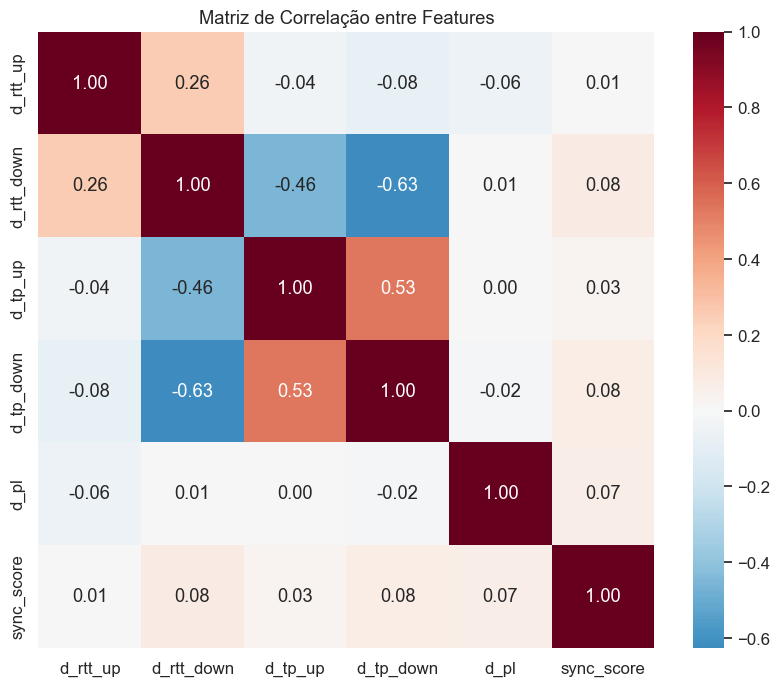

Correlação RTT Down vs TP Down: -0.6252
Correlação RTT Up vs TP Up:     -0.0441


In [73]:
# --- Matriz de Correlação Global ---

plt.figure(figsize=(10, 8))
corr_cols = ['d_rtt_up', 'd_rtt_down', 'd_tp_up', 'd_tp_down', 'd_pl', 'sync_score']
correlation_matrix = df_ana[corr_cols].corr()

# Mapa de calor para identificar dependências multivariadas
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".2f", square=True)

plt.title("Matriz de Correlação entre Features")
plt.show()

# Verificação de simetria Up/Down
print(f"Correlação RTT Down vs TP Down: {correlation_matrix.loc['d_rtt_down', 'd_tp_down']:.4f}")
print(f"Correlação RTT Up vs TP Up:     {correlation_matrix.loc['d_rtt_up', 'd_tp_up']:.4f}")

## 7. Avaliação de Outliers e Dispersão Individual (Boxplots)

Nesta seção, utilizamos diagramas de caixa (boxplots) para analisar a dispersão dos dados e identificar visualmente a presença de pontos extremos (outliers) nas distribuições das variações. Para evitar distorções de escala entre as diferentes naturezas dos dados (latência, vazão e perda de pacotes), cada métrica é plotada em uma figura independente.

### Justificativa Técnica para o Pré-Processamento

* **Sensibilidade do GMM a Outliers:** O algoritmo Expectation-Maximization (EM) empregado na modelagem GMM baseia-se no cálculo de médias ($\mu_{k}$) e matrizes de covariância ($\Sigma_{k}$). Valores extremos desviam drasticamente o centroide do componente e forçam uma expansão geométrica irreal da elipse de covariância, fundindo clusters que deveriam ser distintos.
* **Definição de Limites (Clipping):** A visualização dos quartis e dos pontos que extrapolam o limite interquartil (IQR) fornece o embasamento empírico necessário para definir limiares de corte (por exemplo, os percentis 1% e 99%) antes da etapa de padronização ($z_{e}$).
* **Simetria Direcional:** Permite confirmar se as anomalias extremas possuem uma direção preferencial, como recuperações abruptas de rede (quedas drásticas no RTT) versus falhas severas de saturação.

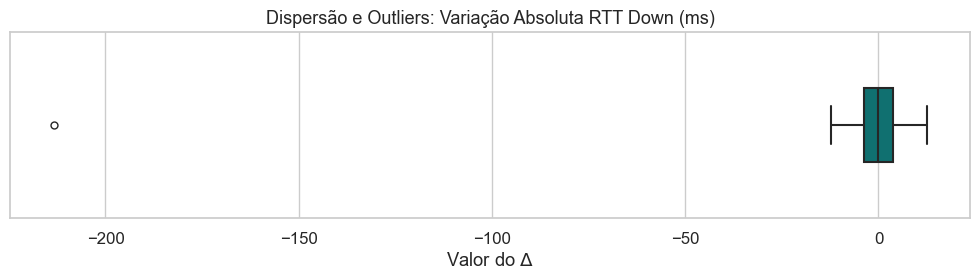

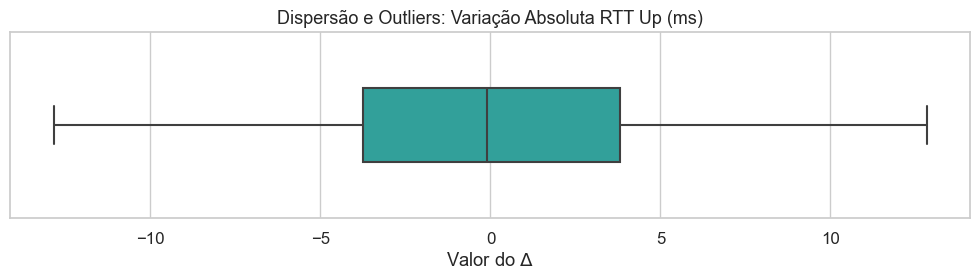

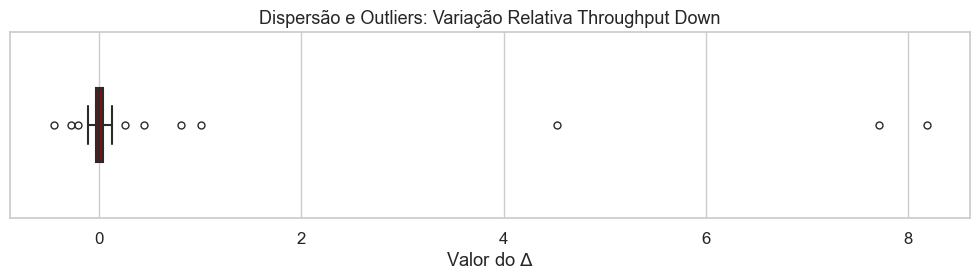

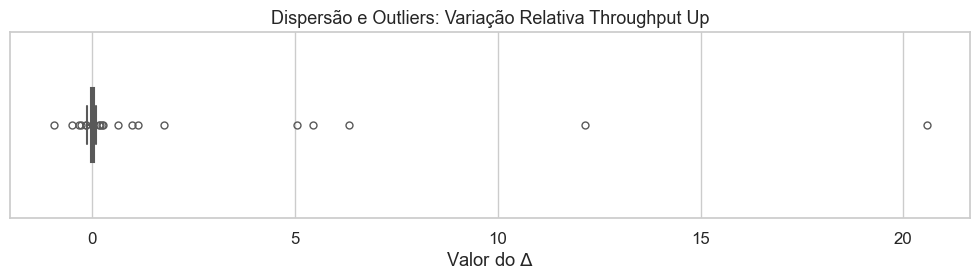

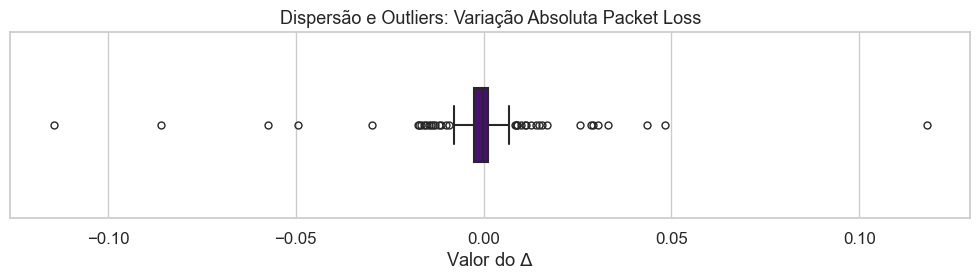

In [74]:
# Configuração das métricas para a plotagem individual dos boxplots
metrics_to_plot_box = [
    ('d_rtt_down', 'Variação Absoluta RTT Down (ms)', 'teal'),
    ('d_rtt_up', 'Variação Absoluta RTT Up (ms)', 'lightseagreen'),
    ('d_tp_down', 'Variação Relativa Throughput Down', 'darkred'),
    ('d_tp_up', 'Variação Relativa Throughput Up', 'indianred'),
    ('d_pl', 'Variação Absoluta Packet Loss', 'indigo')
]

# Geração de uma figura independente para cada métrica
for col, label, color in metrics_to_plot_box:
    if col in df_ana.columns:
        plt.figure(figsize=(10, 3))
        
        # Criação do boxplot horizontal
        sns.boxplot(
            x=df_ana[col], 
            color=color, 
            width=0.4, 
            fliersize=5, 
            linewidth=1.5
        )
        
        plt.title(f"Dispersão e Outliers: {label}", fontsize=13)
        plt.xlabel("Valor do $\\Delta$")
        
        # Ajuste de layout para evitar cortes
        plt.tight_layout()
        plt.show()

## 8. Assinaturas de Rede: Comparação Download vs. Upload

Nesta seção, comparamos visualmente o comportamento das métricas nos sentidos de descida (Download) e subida (Upload). Esta diferenciação é crucial para entender a natureza das anomalias capturadas.

### Análise de Quadrantes e Tabela 1

* **Assimetria de Rede**: Links residenciais e comerciais costumam apresentar dinâmicas de buffer distintas para subida e descida. O GMM precisa saber se deve tratar essas direções como dimensões independentes.
* **Identificação do Cluster de Congestionamento**: Conforme a Tabela 1, o Congestionamento (Cluster 1) é identificado pelo aumento de RTT com queda de Throughput. No gráfico de dispersão, esses pontos devem habitar o quadrante onde o eixo X (RTT) é positivo e o eixo Y (TP) é negativo.
* **Interpretação Semântica**: Ao plotar ambos os sentidos, verificamos se os eventos de mudança são simétricos ou se o gargalo está concentrado em apenas uma direção da comunicação.

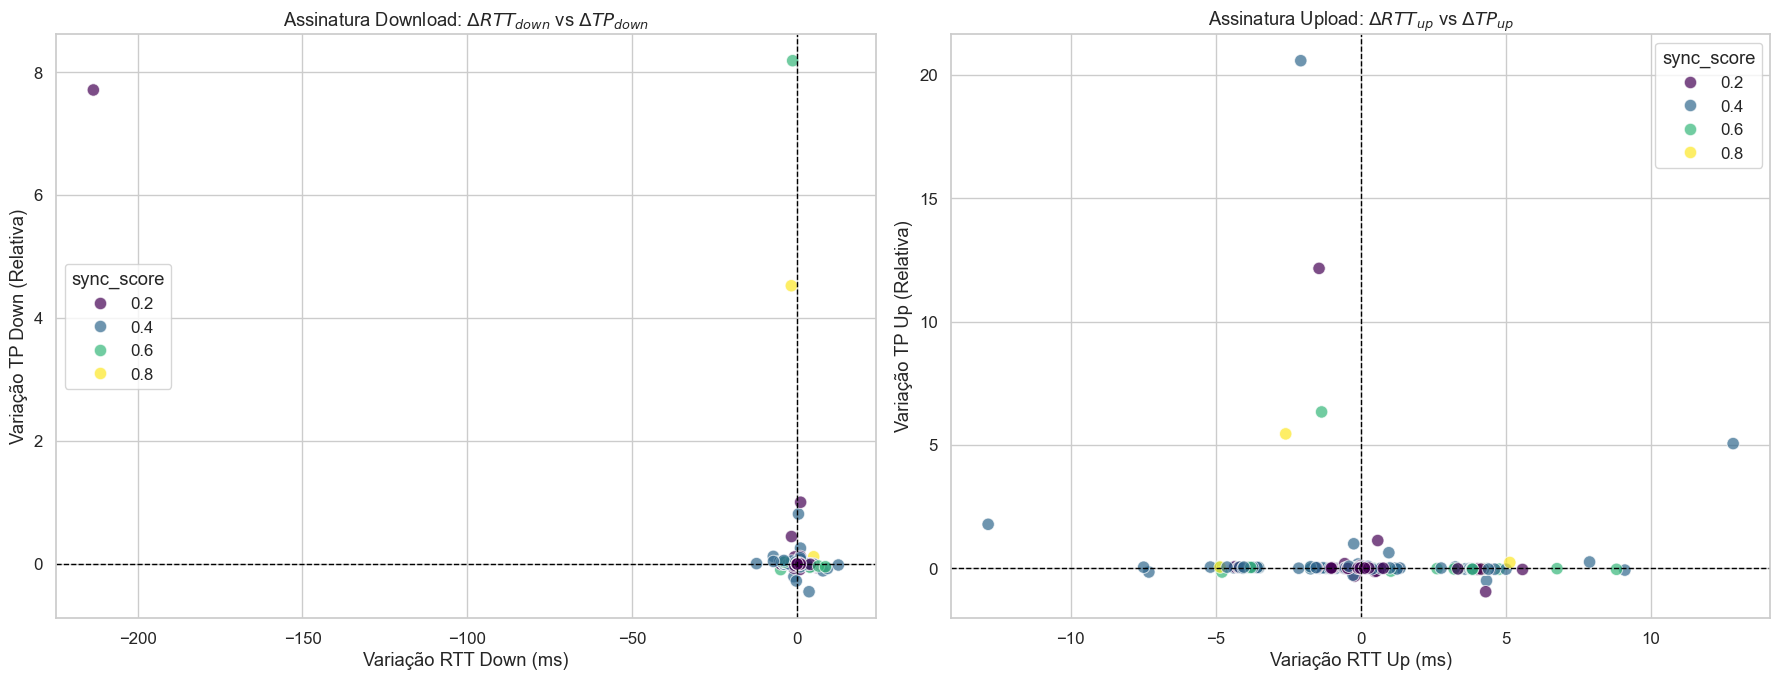

In [75]:
# --- Comparação de Assinaturas: Download vs Upload ---

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. Download: RTT vs Throughput
sns.scatterplot(data=df_ana, x='d_rtt_down', y='d_tp_down', 
                hue='sync_score', palette='viridis', s=80, alpha=0.7, ax=axes[0])
axes[0].axhline(0, color='black', lw=1, ls='--')
axes[0].axvline(0, color='black', lw=1, ls='--')
axes[0].set_title(r"Assinatura Download: $\Delta RTT_{down}$ vs $\Delta TP_{down}$")
axes[0].set_xlabel("Variação RTT Down (ms)")
axes[0].set_ylabel("Variação TP Down (Relativa)")
# axes[0].set_xlim(-50, 50)
# axes[0].set_ylim(-1, 1)

# 2. Upload: RTT vs Throughput
sns.scatterplot(data=df_ana, x='d_rtt_up', y='d_tp_up', 
                hue='sync_score', palette='viridis', s=80, alpha=0.7, ax=axes[1])
axes[1].axhline(0, color='black', lw=1, ls='--')
axes[1].axvline(0, color='black', lw=1, ls='--')
axes[1].set_title(r"Assinatura Upload: $\Delta RTT_{up}$ vs $\Delta TP_{up}$")
axes[1].set_xlabel("Variação RTT Up (ms)")
axes[1].set_ylabel("Variação TP Up (Relativa)")

plt.tight_layout()
plt.show()

## 9. Impacto da Perda de Pacotes ($\Delta PL$)

A perda de pacotes é a métrica de "última instância" para confirmar eventos de congestionamento severo ou degradação física do link.

### Justificativa Técnica para a Classificação

* **Sinalização de Bufferbloat**: Segundo o referencial (Seção 4.1), o aumento de perda de pacotes ($\Delta PL > 0$) combinado com o aumento de atraso confirma que os buffers da rede transbordaram.
* **Separação de Clusters**: Esperamos que o cluster de **Mudança de Rota** (Cluster 2) apresente variações de RTT sem aumento significativo na perda de pacotes ($\Delta PL \approx 0$). Já o cluster de **Congestionamento** deve apresentar uma correlação positiva entre latência e perda.
* **Estabilidade do GMM**: Como a perda de pacotes pode ser esparsa (muitos eventos com perda zero), esta visualização ajuda a decidir se a métrica de PL deve ser tratada com pesos específicos ou pré-processamento adicional antes da entrada no modelo de mistura.

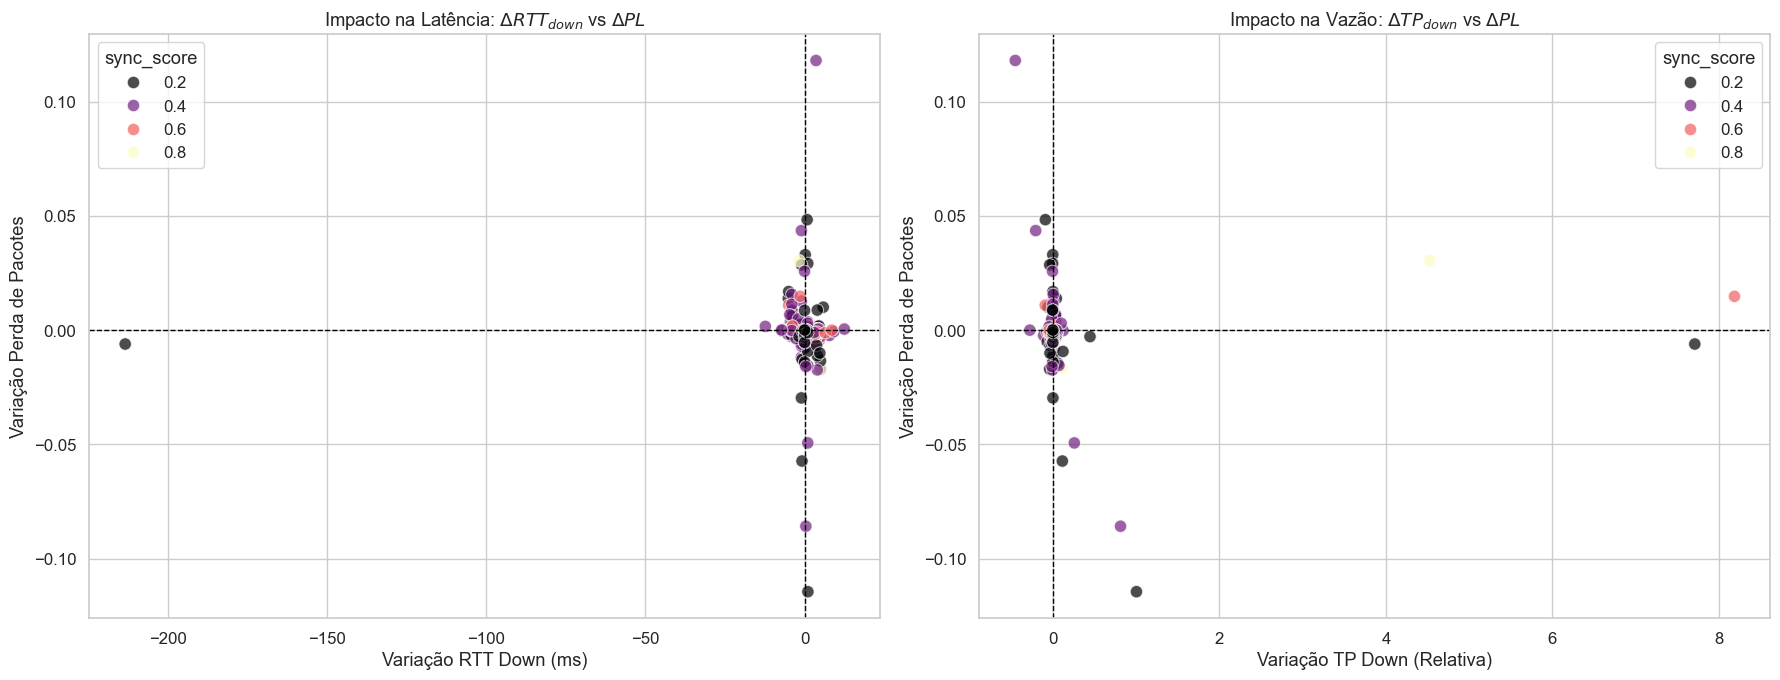

In [76]:
# --- Análise do Impacto da Perda de Pacotes ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. Packet Loss vs RTT Down
sns.scatterplot(data=df_ana, x='d_rtt_down', y='d_pl', 
                hue='sync_score', palette='magma', s=80, alpha=0.7, ax=axes[0])
axes[0].axhline(0, color='black', lw=1, ls='--')
axes[0].axvline(0, color='black', lw=1, ls='--')
axes[0].set_title(r"Impacto na Latência: $\Delta RTT_{down}$ vs $\Delta PL$")
axes[0].set_xlabel("Variação RTT Down (ms)")
axes[0].set_ylabel("Variação Perda de Pacotes")

# 2. Packet Loss vs Throughput Down
sns.scatterplot(data=df_ana, x='d_tp_down', y='d_pl', 
                hue='sync_score', palette='magma', s=80, alpha=0.7, ax=axes[1])
axes[1].axhline(0, color='black', lw=1, ls='--')
axes[1].axvline(0, color='black', lw=1, ls='--')
axes[1].set_title(r"Impacto na Vazão: $\Delta TP_{down}$ vs $\Delta PL$")
axes[1].set_xlabel("Variação TP Down (Relativa)")
axes[1].set_ylabel("Variação Perda de Pacotes")

plt.tight_layout()
plt.show()